In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                           f1_score, roc_auc_score, confusion_matrix,
                           classification_report, roc_curve, precision_recall_curve,
                           average_precision_score)

In [ ]:
print("---Load the Dataset---")
dataset=pd.read_csv("/content/drive/MyDrive/diabetes_prediction_dataset.csv")
dataset

---Load the Dataset---


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [ ]:
print("Shape of Dataset:",dataset.shape)

Shape of Dataset: (100000, 9)


In [ ]:
print("First fews rows of the Dataset:")
dataset.head()

First fews rows of the Dataset:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [ ]:
print("Lasts fews rows of the Dataset:")
dataset.tail()

Lasts fews rows of the Dataset:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0
99999,Female,57.0,0,0,current,22.43,6.6,90,0


In [ ]:
print("Display the full information of Dataset:")
dataset.info()

Display the full information of Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [ ]:
column_dtypes = dataset.dtypes
print(column_dtypes)

gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object


In [ ]:
print("\nMissing values per column:")
dataset.isnull().sum()


Missing values per column:


,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [ ]:
print("Checking Total Duplicate values :",dataset.duplicated().sum())

Checking Total Duplicate values : 3854


In [ ]:
print("Drops the Duplicate value:")
dataset= dataset.drop_duplicates()
print(dataset.shape)

Drops the Duplicate value:
(96146, 9)


In [ ]:
print("\nDisplay the simple statistics:")
dataset.describe()


Display the simple statistics:


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


In [ ]:
print("checking the tolal NAN values:",dataset.isna().sum().sum())

checking the tolal NAN values: 0


In [ ]:
# showing the all features of Gender
dataset['gender'].value_counts()

,count
gender,
Female,56161
Male,39967
Other,18


In [ ]:
# set Gender as 'male','female'
dataset = dataset[dataset.gender != "Other"]
set(dataset.gender)

{'Female', 'Male'}

In [ ]:
# checks the how many 'male' and 'female' exists in dataset
Gender=dataset['gender'].value_counts()
print(Gender)

gender
Female    56161
Male      39967
Name: count, dtype: int64


In [ ]:
# showing the all features of smoking
Smoking=dataset['smoking_history'].value_counts()
print(Smoking)

smoking_history
never          34395
No Info        32881
former          9299
current         9197
not current     6359
ever            3997
Name: count, dtype: int64


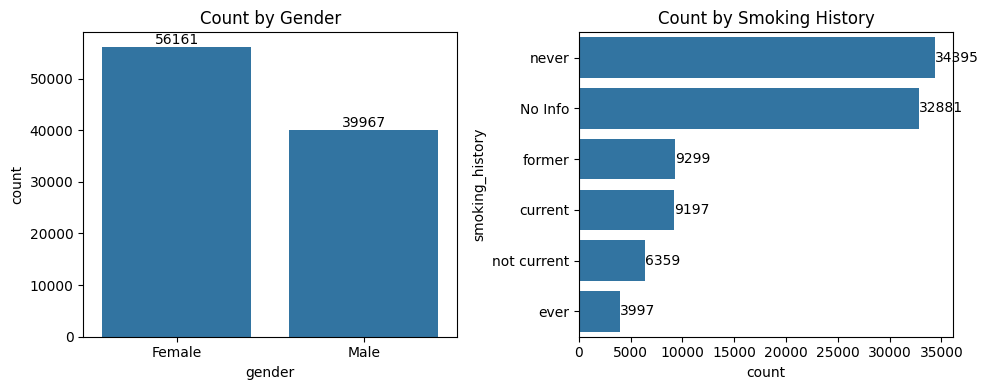

In [ ]:
# viusalization the 'gender' and 'smoking_history' using countplot

plt.figure(figsize=(10,4))
ax=plt.subplot(1,2,1)
ax=sns.countplot(data=dataset, x='gender', order=dataset['gender'].value_counts().index)
ax.bar_label(ax.containers[0])
plt.title('Count by Gender')
plt.xticks(rotation=0)

ax=plt.subplot(1,2,2)
ax=sns.countplot(data=dataset, y='smoking_history', order=dataset['smoking_history'].value_counts().index)
ax.bar_label(ax.containers[0])
plt.title('Count by Smoking History')
plt.tight_layout()
plt.show()

Smoking History: never
Male Smokers: 12056
Female Smokers: 22339
--
Smoking History: No Info
Male Smokers: 14912
Female Smokers: 17969
--
Smoking History: former
Male Smokers: 4556
Female Smokers: 4743
--
Smoking History: current
Male Smokers: 4186
Female Smokers: 5011
--
Smoking History: not current
Male Smokers: 2496
Female Smokers: 3863
--
Smoking History: ever
Male Smokers: 1761
Female Smokers: 2236
--


<Figure size 1000x500 with 0 Axes>

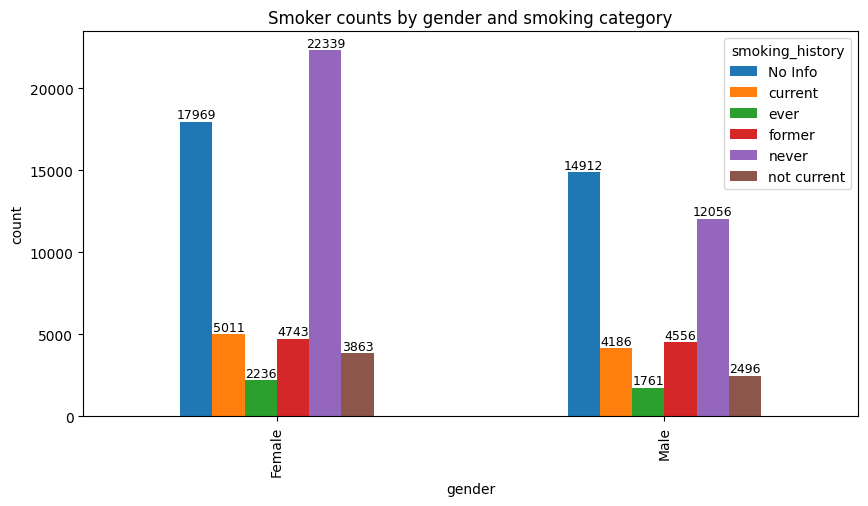

In [ ]:
# showing explicit features of smoking_history
smoking_categories = ["never", "No Info", "former", "current", "not current", "ever"]
for category in smoking_categories:
    male_smokers = dataset[(dataset["gender"] == "Male") & (dataset["smoking_history"] == category)].shape[0]
    female_smokers = dataset[(dataset["gender"] == "Female") & (dataset["smoking_history"] == category)].shape[0]
    print(f"Smoking History: {category}")
    print(f"Male Smokers: {male_smokers}")
    print(f"Female Smokers: {female_smokers}")
    print("-" * 2)

# grouped bar plot with value labels
import matplotlib.pyplot as plt

# grouped data
agg = dataset[dataset['smoking_history'].isin(smoking_categories)]\
        .groupby(['gender','smoking_history']).size().unstack(fill_value=0)

plt.figure(figsize=(10,5))
bar_plot = agg.plot(kind='bar', figsize=(10,5))

plt.title('Smoker counts by gender and smoking category')
plt.xlabel('gender')
plt.ylabel('count')

# --- Add value labels on each bar ---
for p in bar_plot.patches:
    height = p.get_height()
    bar_plot.annotate(
        text=str(height),
        xy=(p.get_x() + p.get_width() / 2, height),
        ha='center', va='bottom',
        fontsize=9
    )

plt.show()


In [ ]:
# Dividing features into Numerical & Categorical
col = list(dataset.columns)
categorical_data = []
numerical_data = []
for i in col:
    if len(dataset[i].unique()) > 10:
        numerical_data.append(i)
    else:
        categorical_data.append(i)
print("Numerical Data :", *numerical_data)
print("Categorical Data :", *categorical_data)

Numerical Data : age bmi HbA1c_level blood_glucose_level
Categorical Data : gender hypertension heart_disease smoking_history diabetes


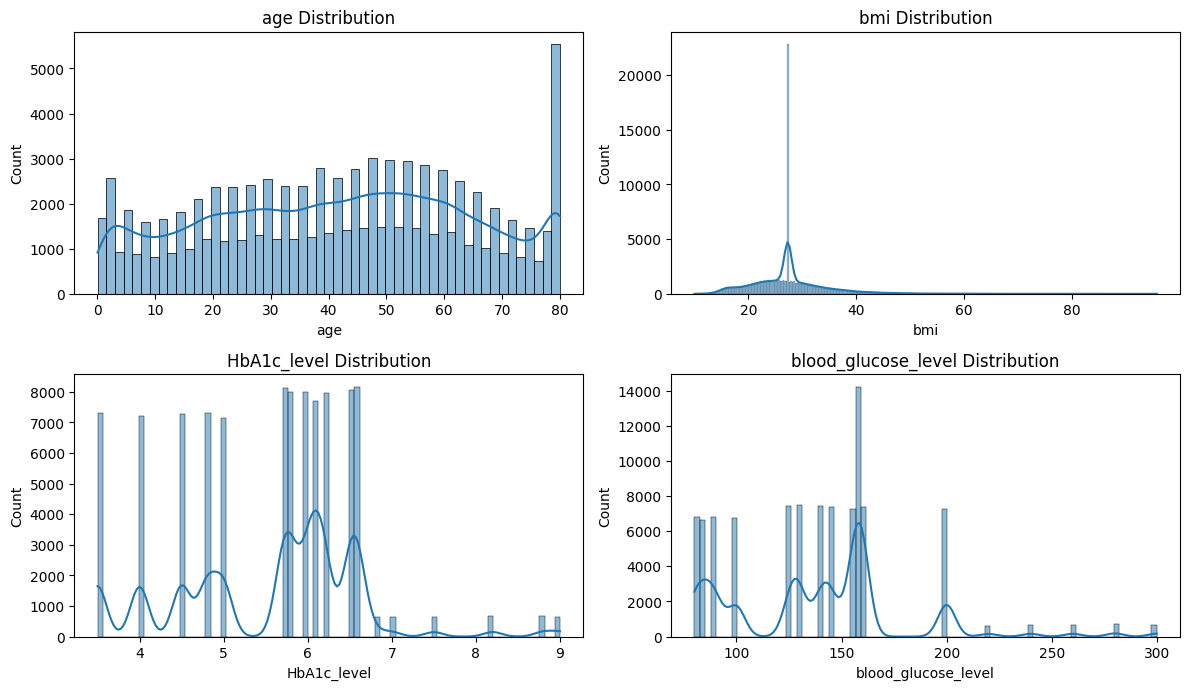

In [ ]:
# viusalization the numerical features using countplot
plt.figure(figsize=(12,10))
for i,col in enumerate(numerical_data,1):
    plt.subplot(3,2,i)
    sns.histplot(dataset[col], kde=True)
    plt.title(f'{col} Distribution')
plt.tight_layout()
plt.show()

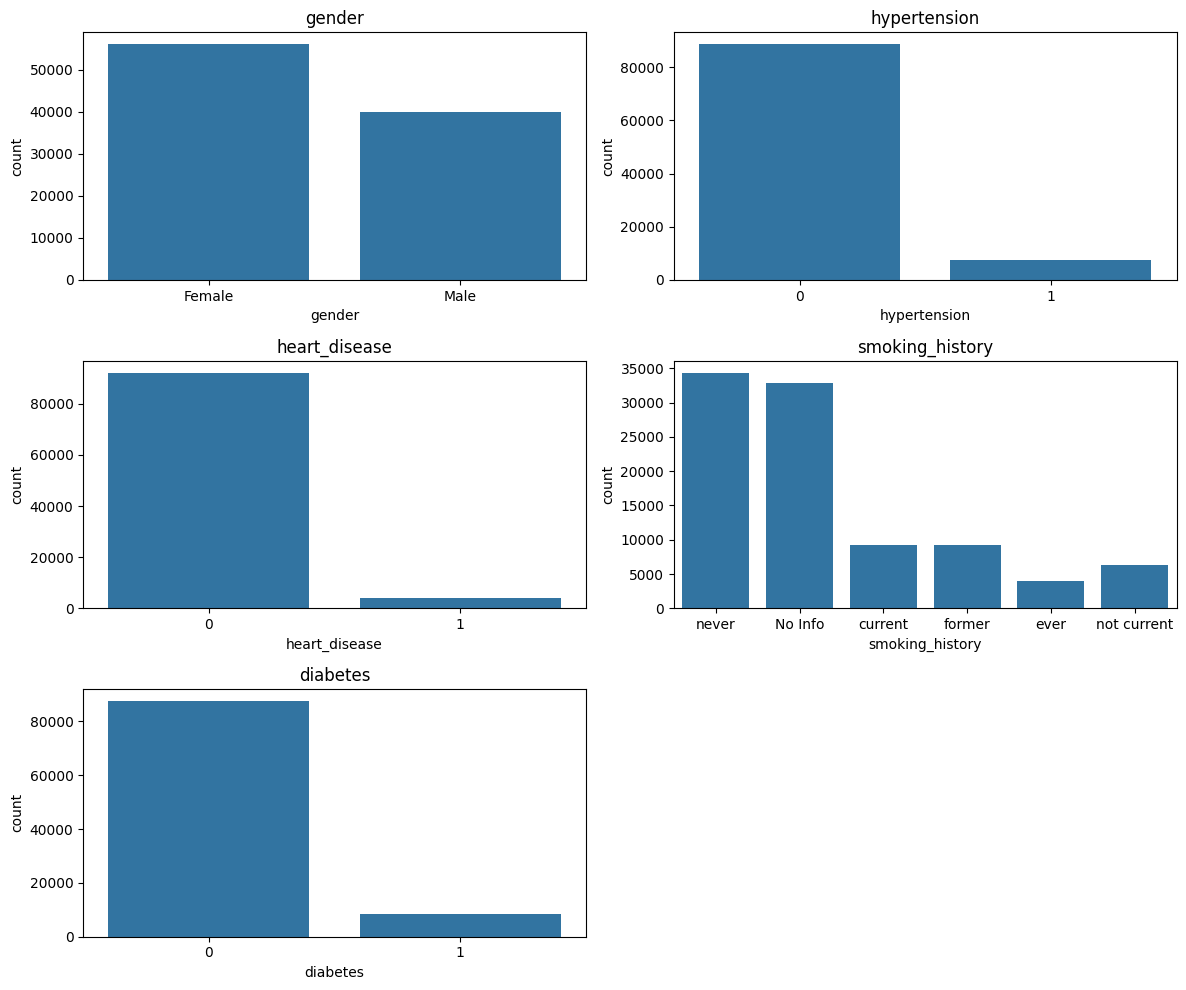

In [ ]:
# viusalization the categorical features using countplot
categorical_cols = ['gender', 'hypertension', 'heart_disease', 'smoking_history','diabetes']

plt.figure(figsize=(12,10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3,2,i)
    sns.countplot(x=dataset[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [ ]:
result = (
    dataset.groupby(["gender", "smoking_history"])["diabetes"]
    .agg(total_people="count", diabetic_people="sum")
    .reset_index()
)

result["diabetes_percent"] = (
    result["diabetic_people"] / result["total_people"] * 100
).round(2)

print("\n=== Diabetes by Smoking History & Gender ===\n")
print(result)



=== Diabetes by Smoking History & Gender ===

    gender smoking_history  total_people  diabetic_people  diabetes_percent
0   Female         No Info         17969              747              4.16
1   Female         current          5011              451              9.00
2   Female            ever          2236              211              9.44
3   Female          former          4743              649             13.68
4   Female           never         22339             1995              8.93
5   Female     not current          3863              394             10.20
6     Male         No Info         14912              698              4.68
7     Male         current          4186              497             11.87
8     Male            ever          1761              261             14.82
9     Male          former          4556              941             20.65
10    Male           never         12056             1342             11.13
11    Male     not current          2496 

In [ ]:
plt.figure(figsize=(12,6))
ax = sns.barplot(data=result, x="smoking_history", y="diabetic_people", hue="gender")

plt.title("Diabetes People by Smoking Category & Gender")
plt.xlabel("Smoking Category")
plt.ylabel("Diabetes people")
plt.xticks(rotation=0)

# --- Add value labels on top of each bar ---
for container in ax.containers:
    ax.bar_label(container, fontsize=9)

plt.legend(title="Gender")
plt.tight_layout()
plt.show()

In [ ]:
age_bins = [0,20,30,40,50,60,70,120]
age_labels = ['0-20','21-30','31-40','41-50','51-60','61-70','70+']

dataset["age_group"] = pd.cut(dataset["age"], bins=age_bins, labels=age_labels)
result_age = (
    dataset.groupby(["gender", "age_group"])["diabetes"]
    .agg(total_people="count", diabetic_people="sum")
    .reset_index()
)

result_age["diabetes_percent"] = (
    result_age["diabetic_people"] / result_age["total_people"] * 100
).round(2)

print("\n=== Diabetes by Age Group & Gender ===\n")
print(result_age)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

ax = sns.lineplot(
    data=result_age,
    x="age_group",
    y="diabetes_percent",
    hue="gender",
    marker="o",
    linewidth=2
)

plt.title("Diabetes Percentage by Age Group and Gender")
plt.ylabel("Diabetes Percentage (%)")
plt.xlabel("Age Group")

plt.ylim(0, result_age["diabetes_percent"].max() + 5)

#  Add percentage labels on each point
for _, row in result_age.iterrows():
    ax.text(
        x=row["age_group"],
        y=row["diabetes_percent"] + 0.5,
        s=f"{row['diabetes_percent']}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.legend(title="Gender")
plt.grid(True)
plt.tight_layout()
plt.show()



In [ ]:
bmi_bins = [0, 18.5, 25, 30, 35, 100]
bmi_labels = [
    "Underweight (<18.5)",
    "Normal (18.5–24.9)",
    "Overweight (25–29.9)",
    "Obese (30–34.9)",
    "Severely Obese (35+)"
]

dataset["bmi_group"] = pd.cut(dataset["bmi"], bins=bmi_bins, labels=bmi_labels, include_lowest=True)

result_bmi = (
    dataset.groupby(["gender", "bmi_group"])["diabetes"]
    .agg(total_people="count", diabetic_people="sum")
    .reset_index()
)

result_bmi["diabetes_percent"] = (
    result_bmi["diabetic_people"] / result_bmi["total_people"] * 100
).round(2)

print("\n=== Diabetes by BMI Group & Gender ===\n")
print(result_bmi)



In [ ]:
plt.figure(figsize=(10,6))
ax = sns.barplot(data=result_bmi, x="bmi_group", y="diabetic_people", hue="gender", palette=["skyblue","salmon"])

plt.title("Diabetes People by BMI Group  & Gender")
plt.xlabel("BMI Group")
plt.ylabel("Diabetes people")
plt.xticks(rotation=0)

# --- Add value labels on top of each bar ---
for container in ax.containers:
    ax.bar_label(container, fontsize=9)

plt.legend(title="Gender")
plt.tight_layout()
plt.show()

In [ ]:
hba1c_bins = [0, 5.7, 6.5, 8.0, 15]
hba1c_labels = ["Normal (<5.7)","Prediabetes (5.7–6.4)", "Diabetes (6.5–7.9)","Severe Diabetes (≥8.0)"]

dataset["hba1c_group"] = pd.cut(
    dataset["HbA1c_level"], bins=hba1c_bins, labels=hba1c_labels)
result_hba1c = (
    dataset.groupby(["gender", "hba1c_group"])["diabetes"]
    .agg(total_people="count", diabetic_people="sum")
    .reset_index()
)

result_hba1c["diabetes_percent"] = (
    result_hba1c["diabetic_people"] / result_hba1c["total_people"] * 100
).round(2)

print("\n=== Diabetes by HbA1c Level & Gender ===\n")
print(result_hba1c)

In [ ]:
plt.figure(figsize=(10,6))

for gender in result_hba1c['gender'].unique():
    subset = result_hba1c[result_hba1c['gender']==gender]
    plt.scatter(subset['hba1c_group'], subset['diabetes_percent'], label=gender, s=100)

    # Add labels
    for i in range(len(subset)):
        plt.text(subset['hba1c_group'].iloc[i],
                 subset['diabetes_percent'].iloc[i] + 0.5,
                 f"{subset['diabetes_percent'].iloc[i]:.2f}",
                 ha='center')

plt.title("Diabetes % by HbA1c Group & Gender")
plt.xlabel("HbA1c Group")
plt.ylabel("Diabetes %")
plt.legend()
plt.show()

In [ ]:
glucose_bins = [0, 100, 126, 200, 500]
glucose_labels = [
    "Normal (<100)","Prediabetes (100–125)","Diabetes (126–199)","Severe Diabetes (≥200)"]

dataset["glucose_group"] = pd.cut(
    dataset["blood_glucose_level"],
    bins=glucose_bins,
    labels=glucose_labels
)
result_glucose = (
    dataset.groupby(["gender", "glucose_group"])["diabetes"]
    .agg(total_people="count", diabetic_people="sum")
    .reset_index()
)

result_glucose["diabetes_percent"] = (
    result_glucose["diabetic_people"] / result_glucose["total_people"] * 100
).round(2)

print("\n=== Diabetes by Blood Glucose Level & Gender (NO SMOTE) ===\n")
print(result_glucose)


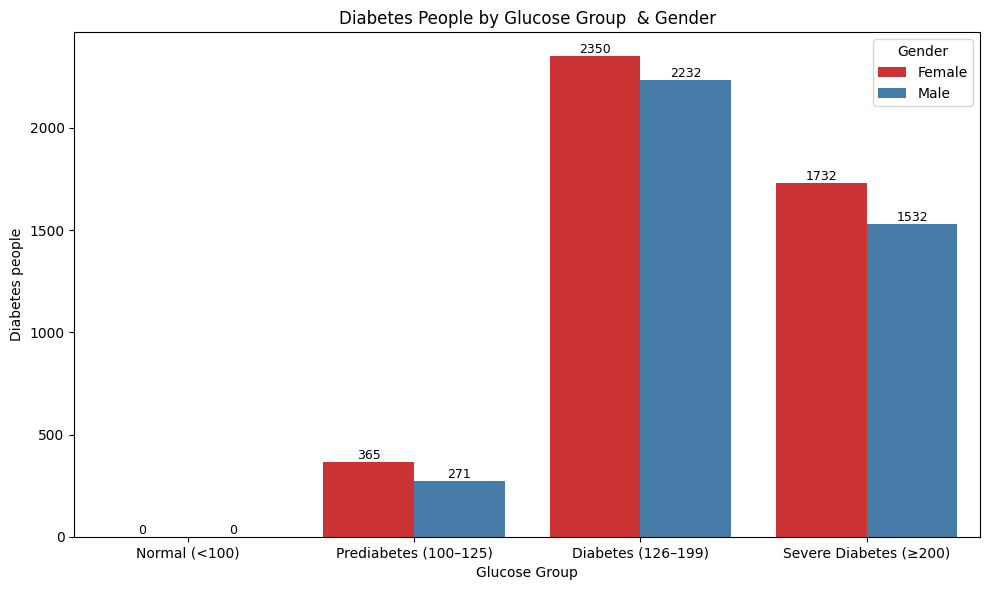

In [ ]:
plt.figure(figsize=(10,6))
ax = sns.barplot(data=result_glucose, x="glucose_group", y="diabetic_people", hue="gender", palette="Set1")

plt.title("Diabetes People by Glucose Group  & Gender")
plt.xlabel("Glucose Group")
plt.ylabel("Diabetes people")
plt.xticks(rotation=0)

# --- Add value labels on top of each bar ---
for container in ax.containers:
    ax.bar_label(container, fontsize=9)

plt.legend(title="Gender")
plt.tight_layout()
plt.show()

In [ ]:
# Encode Gender column{'Female': 0, 'Male': 1}
# Encode smoking_history column {'No Info': 0, 'current': 1, 'ever': 2, 'former': 3, 'never': 4, 'not current': 5}
le_gender = LabelEncoder()
le_smoking = LabelEncoder()

dataset['gender'] = le_gender.fit_transform(dataset['gender'])
dataset['smoking_history'] = le_smoking.fit_transform(dataset['smoking_history'])

# Print readable mappings
gender_mapping = dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_)))
smoking_mapping = dict(zip(le_smoking.classes_, le_smoking.transform(le_smoking.classes_)))

print("Gender Mapping:", gender_mapping)
print(" Smoking History Mapping:", smoking_mapping)

Gender Mapping: {'Female': np.int64(0), 'Male': np.int64(1)}
 Smoking History Mapping: {'No Info': np.int64(0), 'current': np.int64(1), 'ever': np.int64(2), 'former': np.int64(3), 'never': np.int64(4), 'not current': np.int64(5)}


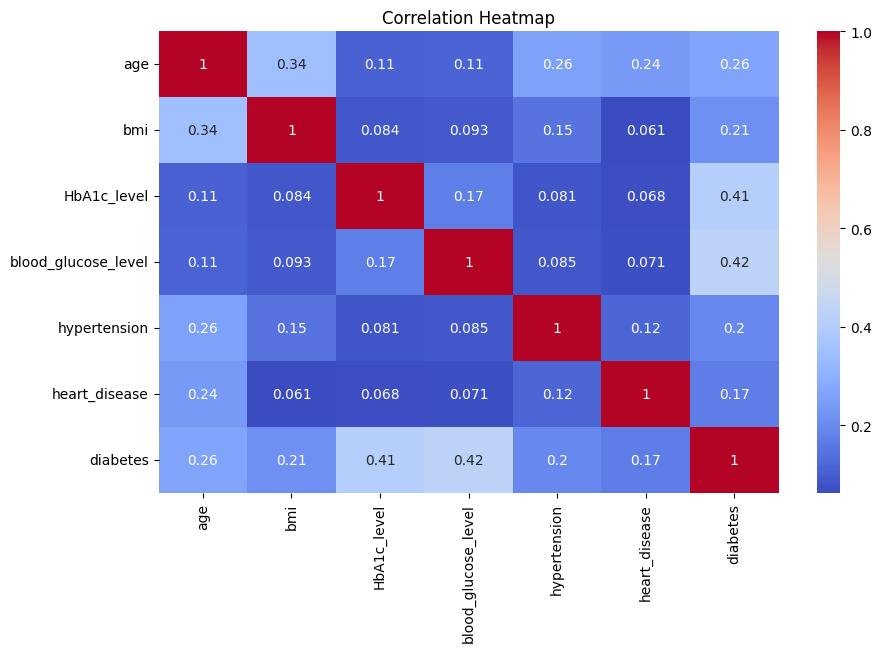

In [ ]:
# correlations between features of the dataset
corr_cols = ['age','bmi','HbA1c_level','blood_glucose_level',
             'hypertension','heart_disease','diabetes']

plt.figure(figsize=(10,6))
sns.heatmap(dataset[corr_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Separate features and target
X = dataset.drop('diabetes', axis=1)
y = dataset['diabetes']
cols_to_drop = ['age_group', 'bmi_group', 'hba1c_group', 'glucose_group']
X = X.drop(columns=cols_to_drop)
# split the data
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
# Percentage of train and test data
train_percentage = (len(X_train) / len(X)) * 100
test_percentage = (len(X_test) / len(X)) * 100

print(f"Training Data Percentage: {train_percentage:.2f}%")
print(f"Testing Data Percentage: {test_percentage:.2f}%")

Train shape: (76902, 8) | Test shape: (19226, 8)
Training Data Percentage: 80.00%
Testing Data Percentage: 20.00%


In [ ]:
# Store original dataset size
original_size = len(dataset)

# Outlier removal function
def remove_outliers(dataset, col):
    Q1 = dataset[col].quantile(0.25)
    Q3 = dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return dataset[(dataset[col] >= lower) & (dataset[col] <= upper)]

# Remove outliers for BMI and Blood Glucose
for c in ['bmi', 'blood_glucose_level']:
    dataset = remove_outliers(dataset, c)


# New dataset size
new_size = len(dataset)

# Outliers removed
removed = original_size - new_size
percentage = (removed / original_size) * 100

# Print results
print("Total records before:", original_size)
print("Total records after:", new_size)
print("Outliers removed:", removed)
print("Percentage removed: {:.2f}%".format(percentage))

Total records before: 96128
Total records after: 89054
Outliers removed: 7074
Percentage removed: 7.36%


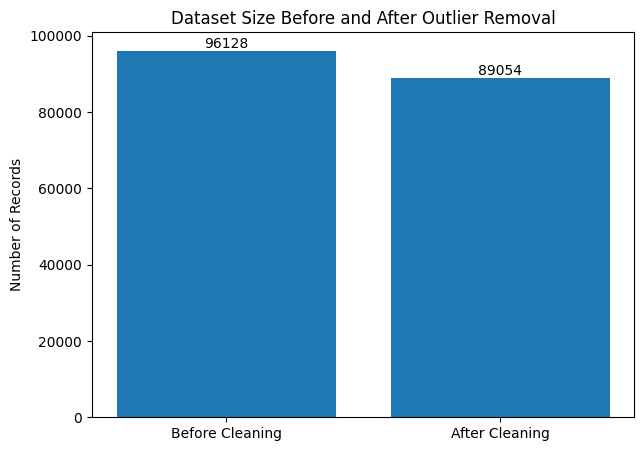

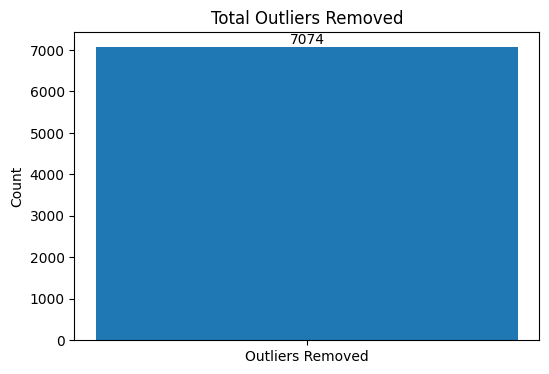

In [ ]:
import matplotlib.pyplot as plt

# Values from your output
original_size = 96128
new_size = 89054
removed = original_size - new_size

# Bar plot
plt.figure(figsize=(7,5))
plt.bar(['Before Cleaning', 'After Cleaning'], [original_size, new_size])
plt.title('Dataset Size Before and After Outlier Removal')
plt.ylabel('Number of Records')

# Annotate values
plt.text(0, original_size, str(original_size), ha='center', va='bottom')
plt.text(1, new_size, str(new_size), ha='center', va='bottom')

plt.show()

# Optional: Plot removed count
plt.figure(figsize=(6,4))
plt.bar(['Outliers Removed'], [removed])
plt.title('Total Outliers Removed')
plt.ylabel('Count')
plt.text(0, removed, str(removed), ha='center', va='bottom')

plt.show()

In [ ]:
# calulates the Diabetes data
print("Before SMOTE:")
print(y_train.value_counts())
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
diabetes
0    70121
1     6781
Name: count, dtype: int64

After SMOTE:
diabetes
0    70121
1    70121
Name: count, dtype: int64


In [ ]:
# Prepare final training and testing sets
 # SMOTE-balanced training data
X_train_final = X_train_smote
y_train_final = y_train_smote
 # original test data (NO SMOTE)
X_test_final = X_test
y_test_final = y_test

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

Model: Logistic Regression
Accuracy: 88.0526
Precision: 0.4143
Recall: 0.8466
F1-Score: 0.5563

Confusion Matrix:
[[15489  2036]
 [  261  1440]]

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.98      0.88      0.93     17525
    Diabetes       0.41      0.85      0.56      1701

    accuracy                           0.88     19226
   macro avg       0.70      0.87      0.74     19226
weighted avg       0.93      0.88      0.90     19226


ROC-AUC Score: 0.9520


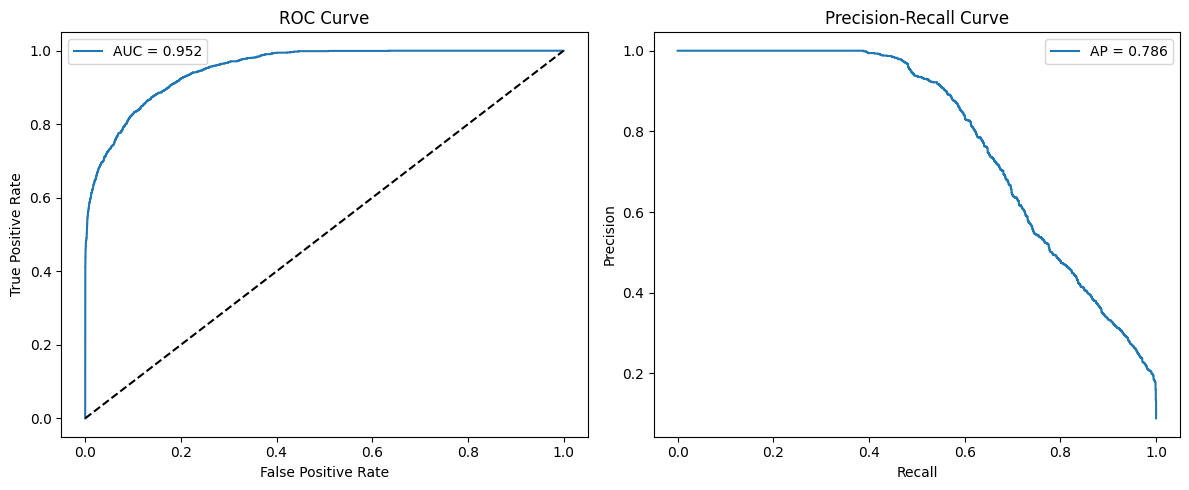

Average Precision Score: 0.7860


In [ ]:
# Create Logistic Regression Model
Logistic_Regression = LogisticRegression(
    random_state=42,
    max_iter=2000
)

# Train Model
Logistic_Regression.fit(X_train_scaled, y_train_final)

# Predictions
y_pred = Logistic_Regression.predict(X_test_scaled)

# Basic Metrics
accuracy = accuracy_score(y_test_final, y_pred)
precision = precision_score(y_test_final, y_pred)
recall = recall_score(y_test_final, y_pred)
f1 = f1_score(y_test_final, y_pred)

# Print Results
print("Model: Logistic Regression")
print(f"Accuracy: {accuracy*100:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_final, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test_final,
    y_pred,
    target_names=["No Diabetes", "Diabetes"]
))

# ===============================
# Extended Evaluation
# ===============================

# Probability predictions
y_prob = Logistic_Regression.predict_proba(X_test_scaled)[:, 1]

# ROC-AUC Score
roc_auc = roc_auc_score(y_test_final, y_prob)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

# Compute curves
fpr, tpr, _ = roc_curve(y_test_final, y_prob)
precision_curve, recall_curve, _ = precision_recall_curve(y_test_final, y_prob)

ap_score = average_precision_score(y_test_final, y_prob)

# Plot Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# Precision-Recall Curve
axes[1].plot(recall_curve, precision_curve, label=f"AP = {ap_score:.3f}")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Average Precision Score: {ap_score:.4f}")

Model: Random Forest
Accuracy: 95.5061
Precision: 0.7572
Recall: 0.7243
F1-Score: 0.7404

Confusion Matrix:
[[17130   395]
 [  469  1232]]

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.97      0.98      0.98     17525
    Diabetes       0.76      0.72      0.74      1701

    accuracy                           0.96     19226
   macro avg       0.87      0.85      0.86     19226
weighted avg       0.95      0.96      0.95     19226


ROC-AUC Score: 0.9650


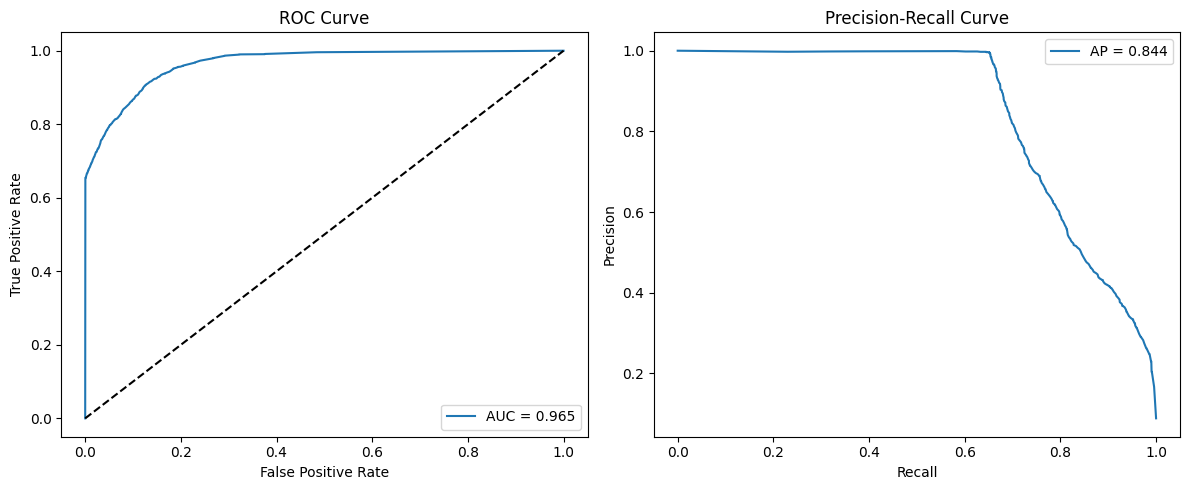

Average Precision Score: 0.8439


In [ ]:
# Create Random Forest Model
Random_Forest= RandomForestClassifier(n_estimators=200, random_state=42)

# Train Model
Random_Forest.fit(X_train_final, y_train_final)

# Predictions
y_pred = Random_Forest.predict(X_test_final)


# Basic Metrics
accuracy = accuracy_score(y_test_final, y_pred)
precision = precision_score(y_test_final, y_pred)
recall = recall_score(y_test_final, y_pred)
f1 = f1_score(y_test_final, y_pred)

# Print Results
print("Model: Random Forest")
print(f"Accuracy: {accuracy*100:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_final, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test_final,
    y_pred,
    target_names=["No Diabetes", "Diabetes"]
))

# ===============================
# Extended Evaluation
# ===============================

# Probability predictions
y_prob = Random_Forest.predict_proba(X_test_final)[:, 1]
y_pred = Random_Forest.predict(X_test_final)

# ROC-AUC Score
roc_auc = roc_auc_score(y_test_final, y_prob)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

# Compute curves
fpr, tpr, _ = roc_curve(y_test_final, y_prob)
precision_curve, recall_curve, _ = precision_recall_curve(y_test_final, y_prob)

ap_score = average_precision_score(y_test_final, y_prob)

# Plot Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# Precision-Recall Curve
axes[1].plot(recall_curve, precision_curve, label=f"AP = {ap_score:.3f}")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Average Precision Score: {ap_score:.4f}")

Model:  XGBoost
Accuracy: 96.3175
Precision: 0.8499
Recall: 0.7090
F1-Score: 0.7731

Confusion Matrix:
[[17312   213]
 [  495  1206]]

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.97      0.99      0.98     17525
    Diabetes       0.85      0.71      0.77      1701

    accuracy                           0.96     19226
   macro avg       0.91      0.85      0.88     19226
weighted avg       0.96      0.96      0.96     19226


ROC-AUC Score: 0.9728


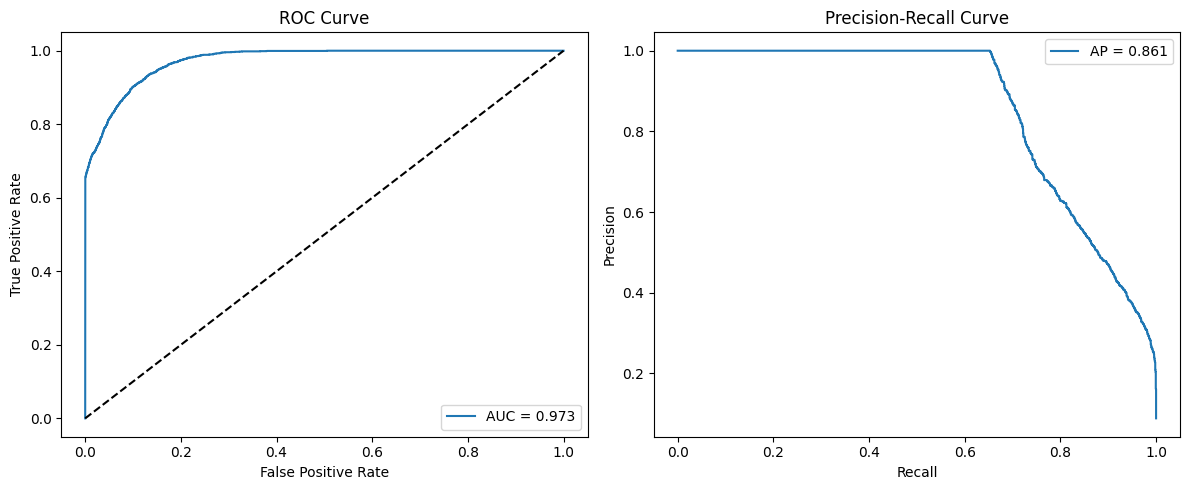

Average Precision Score: 0.8614


In [ ]:
# Create XGBoost Model
XGBoost = XGBClassifier(eval_metric='logloss', random_state=42)

# Train Model
XGBoost.fit(X_train_final, y_train_final)

# Predictions
y_pred = XGBoost.predict(X_test_final)


# Basic Metrics
accuracy = accuracy_score(y_test_final, y_pred)
precision = precision_score(y_test_final, y_pred)
recall = recall_score(y_test_final, y_pred)
f1 = f1_score(y_test_final, y_pred)

# Print Results
print("Model:  XGBoost")
print(f"Accuracy: {accuracy*100:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_final, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test_final,
    y_pred,
    target_names=["No Diabetes", "Diabetes"]
))

# ===============================
# Extended Evaluation
# ===============================

# Probability predictions
y_prob =  XGBoost.predict_proba(X_test_final)[:, 1]
y_pred =  XGBoost.predict(X_test_final)

# ROC-AUC Score
roc_auc = roc_auc_score(y_test_final, y_prob)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

# Compute curves
fpr, tpr, _ = roc_curve(y_test_final, y_prob)
precision_curve, recall_curve, _ = precision_recall_curve(y_test_final, y_prob)

ap_score = average_precision_score(y_test_final, y_prob)

# Plot Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# Precision-Recall Curve
axes[1].plot(recall_curve, precision_curve, label=f"AP = {ap_score:.3f}")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Average Precision Score: {ap_score:.4f}")

In [ ]:
# Create Support Vector Machine Model
from sklearn.svm import SVC
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale'
)

# Train Model
svm_model.fit(X_train_scaled, y_train_final)

# Predictions
y_pred_svm = svm_model.predict(X_test_scaled)

# Basic Metrics
accuracy = accuracy_score(y_test_final, y_pred_svm)
precision = precision_score(y_test_final, y_pred_svm)
recall = recall_score(y_test_final, y_pred_svm)
f1 = f1_score(y_test_final, y_pred_svm)

# Print Results
print("Model: Support Vector Machine")
print(f"Accuracy: {accuracy*100:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("Confusion Matrix:\n", confusion_matrix(y_test_final, y_pred_svm))
print("Classification Report:\n", classification_report(y_test_final, y_pred_svm, target_names=["No Diabetes", "Diabetes"]
 ))

Model: Support Vector Machine
Accuracy: 88.8172
Precision: 0.4336
Recall: 0.8624
F1-Score: 0.5771
Confusion Matrix:
 [[15609  1916]
 [  234  1467]]
Classification Report:
               precision    recall  f1-score   support

 No Diabetes       0.99      0.89      0.94     17525
    Diabetes       0.43      0.86      0.58      1701

    accuracy                           0.89     19226
   macro avg       0.71      0.88      0.76     19226
weighted avg       0.94      0.89      0.90     19226



In [ ]:
import sys
!{sys.executable} -m pip install tensorflow

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
# Build ANN Model
ann_model = Sequential()

# Input layer + Hidden layer
ann_model.add(Dense(units=64, activation='relu', input_dim=X_train_scaled.shape[1]))

# Hidden layer
ann_model.add(Dense(units=32, activation='relu'))

# Dropout (avoid overfitting)
ann_model.add(Dropout(0.3))

# Output layer (binary classification)
ann_model.add(Dense(units=1, activation='sigmoid'))

In [ ]:
# Compile Model
ann_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
# Train Model
history = ann_model.fit(
    X_train_scaled,
    y_train_final,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.8930 - loss: 0.2283 - val_accuracy: 0.8866 - val_loss: 0.2459
Epoch 2/20
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.9097 - loss: 0.1833 - val_accuracy: 0.9048 - val_loss: 0.2099
Epoch 3/20
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.9136 - loss: 0.1743 - val_accuracy: 0.8858 - val_loss: 0.2389
Epoch 4/20
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.9154 - loss: 0.1712 - val_accuracy: 0.8985 - val_loss: 0.2258
Epoch 5/20
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.9167 - loss: 0.1691 - val_accuracy: 0.8924 - val_loss: 0.2310
Epoch 6/20
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.9167 - loss: 0.1682 - val_accuracy: 0.8838 - val_loss: 0.2245
Epoch 7/20
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.9168 - loss: 0.1678 - val_accuracy: 0.9067 - val_loss: 0.2014
Epoch 8/20
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.9181 - loss: 0

In [ ]:
# Evalute Model
y_pred_prob = ann_model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("ANN Results:")
print("Accuracy:", accuracy_score(y_test_final, y_pred))
print("Precision:", precision_score(y_test_final, y_pred))
print("Recall:", recall_score(y_test_final, y_pred))
print("F1 Score:", f1_score(y_test_final, y_pred))

601/601 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
ANN Results:
Accuracy: 0.9432539269738895
Precision: 0.6483463035019456
Recall: 0.7836566725455615
F1 Score: 0.7096087303699761


SVM model training complete.

Model: Support Vector Machine
Accuracy: 88.8172
Precision: 0.4336
Recall: 0.8624
F1-Score: 0.5771

Confusion Matrix:
 [[15609  1916]
 [  234  1467]]

Classification Report:
               precision    recall  f1-score   support

 No Diabetes       0.99      0.89      0.94     17525
    Diabetes       0.43      0.86      0.58      1701

    accuracy                           0.89     19226
   macro avg       0.71      0.88      0.76     19226
weighted avg       0.94      0.89      0.90     19226


ROC-AUC Score: 0.9544


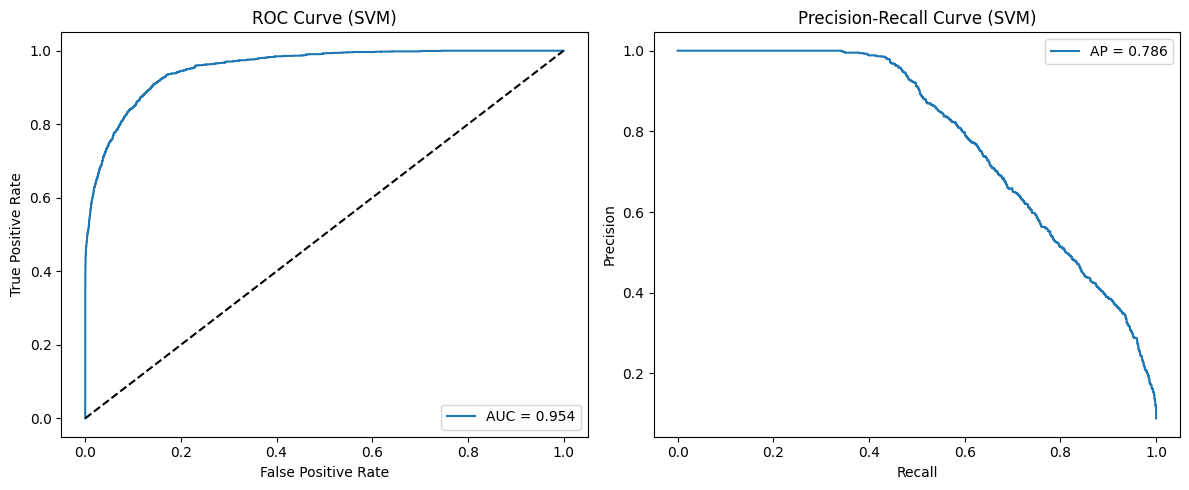

Average Precision Score (SVM): 0.7857


In [ ]:

# Create Support Vector Machine Model
from sklearn.svm import SVC
svm_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

# Train Model
svm_model.fit(X_train_scaled, y_train_final)
print("SVM model training complete.")

# Predictions
y_pred_svm = svm_model.predict(X_test_scaled)

# Basic Metrics
accuracy = accuracy_score(y_test_final, y_pred_svm)
precision = precision_score(y_test_final, y_pred_svm)
recall = recall_score(y_test_final, y_pred_svm)
f1 = f1_score(y_test_final, y_pred_svm)

# Print Results
print("\nModel: Support Vector Machine")
print(f"Accuracy: {accuracy*100:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nConfusion Matrix:\n", confusion_matrix(y_test_final, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test_final, y_pred_svm, target_names=["No Diabetes", "Diabetes"]
 ))

# ===============================
# Extended Evaluation for SVC with probability=True
# ===============================

# Probability predictions
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

# ROC-AUC Score
roc_auc_svm = roc_auc_score(y_test_final, y_prob_svm)
print(f"\nROC-AUC Score: {roc_auc_svm:.4f}")

# Compute curves
fpr_svm, tpr_svm, _ = roc_curve(y_test_final, y_prob_svm)
precision_curve_svm, recall_curve_svm, _ = precision_recall_curve(y_test_final, y_prob_svm)

ap_score_svm = average_precision_score(y_test_final, y_prob_svm)

# Plot Curves
fig_svm, axes_svm = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
axes_svm[0].plot(fpr_svm, tpr_svm, label=f"AUC = {roc_auc_svm:.3f}")
axes_svm[0].plot([0,1],[0,1],'k--')
axes_svm[0].set_title("ROC Curve (SVM)")
axes_svm[0].set_xlabel("False Positive Rate")
axes_svm[0].set_ylabel("True Positive Rate")
axes_svm[0].legend()

# Precision-Recall Curve
axes_svm[1].plot(recall_curve_svm, precision_curve_svm, label=f"AP = {ap_score_svm:.3f}")
axes_svm[1].set_title("Precision-Recall Curve (SVM)")
axes_svm[1].set_xlabel("Recall")
axes_svm[1].set_ylabel("Precision")
axes_svm[1].legend()

plt.tight_layout()
plt.show()

print(f"Average Precision Score (SVM): {ap_score_svm:.4f}")

In [ ]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 27.9 MB/s eta 0:00:00
